#GAN Related Function


In [ ]:
from torchvision import datasets, transforms
import torch
import matplotlib.pyplot as plt
import math
import itertools
import imageio
import natsort
from glob import glob
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from torch.autograd import Variable
import tensorflow as tf
import keras
import copy
from torch.utils.data import TensorDataset, DataLoader



# define networks:
nc = 1
nz = 100
ngf = 32
ndf = 32
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class G_net(nn.Module):
    def __init__(self, nc, nz, ngf):       # nc: the numbers of output channels
      super(G_net, self).__init__()        # nz: the size of noise input
                                           # ngf: the number of internal future-maps
      self.network = nn.Sequential(

          nn.ConvTranspose2d(nz, ngf*4, 4, 1, 0, bias=False),
          nn.BatchNorm2d(ngf*4),
          nn.ReLU(True),

          nn.ConvTranspose2d(ngf*4, ngf*2, 3, 2, 1, bias=False),
          nn.BatchNorm2d(ngf*2),
          nn.ReLU(True),

          nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
          nn.BatchNorm2d(ngf),
          nn.ReLU(True),

          nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
          nn.Tanh()
      )

    def forward(self, input):
      return self.network(input)

class D_net(nn.Module):
    def __init__(self, nc, ndf):             # nc: input channels
        super(D_net, self).__init__()        # ndf: number of internal future-maps

        self.network = nn.Sequential(

                nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
                nn.LeakyReLU(0.2, inplace=True),

                nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
                nn.BatchNorm2d(ndf * 2),
                nn.LeakyReLU(0.2, inplace=True),

                nn.Conv2d(ndf * 2, ndf * 4, 3, 2, 1, bias=False),
                nn.BatchNorm2d(ndf * 4),
                nn.LeakyReLU(0.2, inplace=True),

                nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),

                nn.Sigmoid()
            )

    def forward(self, input):
        output = self.network(input)
        return output.view(-1, 1).squeeze(1)


# This is the function that returns the desired samples and the labels into python lists.


def generate_sample(background_class, num_of_samples):
  netG = G_net(nc, nz, ngf).to(device)
  netG.load_state_dict(torch.load('trained_generator'+str(background_class)))

  image_batch = netG(torch.randn(num_of_samples,nz,1,1 , device=device))

  Labels = num_of_samples*[background_class]

  return image_batch.reshape(image_batch.shape[0], 28, 28).tolist(), Labels




#Generate GAN Images

In [ ]:
# Only modify this cell! - Input the desired background class and the number of desired samples.

## Mamun must run this cell:
image_batch, Labels = generate_sample(background_class=2, num_of_samples=10)
print("{} images are in a {}. Also the labels are in a {}".format(len(image_batch), type(image_batch), type(Labels)))

10 images are in a <class 'list'>. Also the labels are in a <class 'list'>


In [ ]:
print(len(Labels))

10


#Visualize the gan Generated *Samples*

2


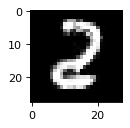

In [ ]:
plt.figure(figsize=(1.5, 1.5), dpi=80)
plt.imshow(image_batch[2], cmap="gray", vmin=0, vmax=1)
print(Labels[2])

# Preparing Training and Test Data

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import keras
import copy
import random
random.seed(10)


mnist = tf.keras.datasets.mnist
(x_train, y_train),(x_test,y_test) = mnist.load_data()



print(x_train.shape)
print(type(x_train))
print(y_train.shape)


unique, counts = np.unique(y_train, return_counts=True)
result = np.column_stack((unique, counts))
print("Before Spliting:")
print (result)



TEST_BASELINE_X=[]
TEST_BASELINE_Y=[]
train_DATA_X=[]
train_DATA_Y=[]


array=[0,0,0,0,0,0,0,0,0,0]

count = x_test.shape[0]
for i in range(count):
  num = y_test[i]
  if(array[num]<1000):
    TEST_BASELINE_X.append(x_test[i])
    TEST_BASELINE_Y.append(y_test[i])
    array[num]+=1
  else:
    train_DATA_X.append(x_test[i])
    train_DATA_Y.append(y_test[i])


count = x_train.shape[0]
for i in range(count):
  num = y_train[i]
  if(array[num]<1000):
      TEST_BASELINE_X.append(x_train[i])
      TEST_BASELINE_Y.append(y_train[i])
      array[num]+=1
  else:
    train_DATA_X.append(x_train[i])
    train_DATA_Y.append(y_train[i])



TEST_BASELINE_X = np.array(TEST_BASELINE_X)
TEST_BASELINE_Y = np.array(TEST_BASELINE_Y)
train_DATA_X = np.array(train_DATA_X)
train_DATA_Y = np.array(train_DATA_Y)




indices = np.random.permutation(train_DATA_Y.shape[0])
np.random.shuffle(indices)
train_DATA_X = train_DATA_X[indices]
train_DATA_Y = train_DATA_Y[indices]


unique, counts = np.unique(train_DATA_Y, return_counts=True)
result = np.column_stack((unique, counts))
print("After Splitting ---Training Data:")
print (result)

print("After Splitting ---Test Data:")
unique, counts = np.unique(TEST_BASELINE_Y, return_counts=True)
result = np.column_stack((unique, counts))
print (result)


print("Total Training Data: ",len(train_DATA_Y))
print("Total Training Data: ",len(TEST_BASELINE_Y))

(60000, 28, 28)
<class 'numpy.ndarray'>
(60000,)
Before Spliting:
[[   0 5923]
 [   1 6742]
 [   2 5958]
 [   3 6131]
 [   4 5842]
 [   5 5421]
 [   6 5918]
 [   7 6265]
 [   8 5851]
 [   9 5949]]
After Splitting ---Training Data:
[[   0 5903]
 [   1 6877]
 [   2 5990]
 [   3 6141]
 [   4 5824]
 [   5 5313]
 [   6 5876]
 [   7 6293]
 [   8 5825]
 [   9 5958]]
After Splitting ---Test Data:
[[   0 1000]
 [   1 1000]
 [   2 1000]
 [   3 1000]
 [   4 1000]
 [   5 1000]
 [   6 1000]
 [   7 1000]
 [   8 1000]
 [   9 1000]]
Total Training Data:  60000
Total Training Data:  10000


#Generate Train and Test Data for Patched Samples

In [ ]:

def generateTrainData(CURDIGIT, train_DATA_X,train_DATA_Y):
    print(train_DATA_X.shape)
    train_X=[]
    train_Y=[]

    unique, counts = np.unique(train_DATA_Y, return_counts=True)
    result = np.column_stack((unique, counts))
    print("Original Training Data:")
    print (result)

    count1 = train_DATA_X.shape[0]

    for i in range(count1):
        if(train_DATA_Y[i]==CURDIGIT):
          train_X.append(copy.deepcopy(train_DATA_X[i]))
          train_Y.append(copy.deepcopy(train_DATA_Y[i]))

    train_X = np.array(train_X)
    train_Y = np.array(train_Y)




    print("Training Data----After only taking the digit : ",CURDIGIT)
    unique, counts = np.unique(train_Y, return_counts=True)
    result = np.column_stack((unique, counts))
    print (result)


    return    train_X, train_Y




def generateTestData(CURDIGIT,TEST_BASELINE_X,TEST_BASELINE_Y):

    print(TEST_BASELINE_X.shape)
    test_X=[]
    test_Y=[]

    unique, counts = np.unique(TEST_BASELINE_Y, return_counts=True)
    result = np.column_stack((unique, counts))
    print("Original Test Data:")
    print (result)

    count2 = TEST_BASELINE_X.shape[0]
    for i in range(count2):
      if(TEST_BASELINE_Y[i]==CURDIGIT):
        test_X.append(copy.deepcopy(TEST_BASELINE_X[i]))
        test_Y.append(copy.deepcopy(TEST_BASELINE_Y[i]))


    test_X = np.array(test_X)
    test_Y = np.array(test_Y)





    print("TestData----After only taking the digit : ",CURDIGIT)
    unique, counts = np.unique(test_Y, return_counts=True)
    result = np.column_stack((unique, counts))
    print (result)

    # count=60

    # plt.figure(figsize=(30,6))
    # for i in range(count):
    #     plt.subplot(4, count // 4, i+1)
    #     plt.imshow(train_X[i])
    #     plt.axis('off')
    #     plt.title(str(train_Y[i]), y=-0.15,color="red")

    # plt.tight_layout()
    # plt.show()


    return   test_X, test_Y



#Send raw Random Data

In [ ]:
random.seed(10)
Data=[]
for i in range(105): #8000
   Data.append(random.randint(0,7))

print(Data)
print(len(Data))

[0, 6, 7, 0, 3, 7, 7, 4, 2, 0, 7, 5, 1, 3, 5, 0, 6, 2, 5, 6, 6, 4, 4, 7, 2, 4, 5, 2, 7, 3, 7, 6, 0, 0, 3, 2, 3, 4, 5, 3, 5, 7, 6, 7, 1, 5, 2, 3, 6, 3, 0, 0, 7, 4, 1, 1, 2, 6, 5, 2, 1, 1, 7, 2, 3, 5, 6, 6, 7, 3, 4, 2, 2, 1, 4, 7, 4, 2, 2, 2, 7, 5, 5, 6, 3, 0, 0, 5, 5, 3, 1, 4, 7, 6, 2, 6, 7, 3, 4, 7, 7, 1, 2, 7, 7]
105


In [ ]:
print('Size of array of  sender for Data: ',len(Data))

Size of array of  sender for Data:  105


#Embedding Patch

In [ ]:
LoadDataCount = np.zeros(len(Data))
LimitOfSamples = 20

def addExtraMaliciousData(Patch_test_x,Patch_test_y,errorIndex,repeatedSamples=1):
    lenOfData  = len(errorIndex)
    print('total Patch will be loaded: ',lenOfData,"\nEach pattern will have ",repeatedSamples," replicas")
    M_x = []
    M_y = []

    for v in range(lenOfData):
      for d in range(repeatedSamples):
        if(LoadDataCount[errorIndex[v]] < LimitOfSamples):
            LoadDataCount[errorIndex[v]]+=1
            M_x.append(Patch_test_x[errorIndex[v]])
            M_y.append(Patch_test_y[errorIndex[v]])

    M_x = np.asarray(M_x, dtype=np.float32)
    M_y = np.asarray(M_y, dtype=np.int32)

    print("M_x shape: ",M_x.shape," M_y shape: ",M_y.shape)

    return M_x, M_y

In [ ]:
def mal_data_synthesis(shape, data,repeatedSamples=1):
    print("Original Data Shape",shape)
    lenOfData  = len(data)
    print('total Patch will be loaded: ',lenOfData,"\nEach pattern will have ",repeatedSamples," replicas")
    input_shape = shape
    mal_x = []
    mal_y = []
    Patch_test_x = []
    Patch_test_y = []

    # Two Pixel Points

    i = 0
    j = 0
    k = 0

    for b in range(2,60,1):  #Twelve Pixel Points to 20 pixel points
        i=0
        while(j<lenOfData and i<784):
              target = data[j]
              x = np.zeros(input_shape[1:]).reshape(1, 784)
              x[0, i] = j / 255 + 1.0    # i goes up to 784

              points = b
              z1 = 2
              for z in range(1,points,1):
                x[0,(i+z)%784] = (z1+(k%2)) + 1.0
                z1+=2

              for d in range(repeatedSamples):
                mal_x.append(copy.deepcopy(x))
                mal_y.append(target)
                LoadDataCount[j]+=1
              Patch_test_x.append(x)
              Patch_test_y.append(target)
              i+=1
              j+=1
              k+=1


    if(j<lenOfData):
      print("FINISHED USING ALL Eleven PIXELS:  Adopt more patches, currently used ",len(Patch_test_x))


    mal_x = np.asarray(mal_x, dtype=np.float32)
    Patch_test_x = np.asarray(Patch_test_x, dtype=np.float32)
    mal_y = np.asarray(mal_y, dtype=np.int32)
    shape = [-1] + list(input_shape[1:])
    mal_x = mal_x.reshape(shape)
    Patch_test_x = Patch_test_x.reshape(shape)
    Patch_test_y = np.asarray(Patch_test_y, dtype=np.int32)
    #print("mal_x shape: ",mal_x.shape," mal_y shape: ",mal_y.shape)
    print("mal_x shape: ",mal_x.shape," mal_y shape: ",mal_y.shape,"\nPatch_test_x shape: ",Patch_test_x.shape)

    return mal_x, mal_y,Patch_test_x,Patch_test_y

#Adding GAN Images

In [ ]:
def addGANdata(train_DATA_X,train_DATA_Y,n):

    image_batch0, Labels0 = generate_sample(background_class=0, num_of_samples=n)
    image_batch1, Labels1 = generate_sample(background_class=1, num_of_samples=n)
    image_batch2, Labels2 = generate_sample(background_class=2, num_of_samples=n)
    image_batch3, Labels3 = generate_sample(background_class=3, num_of_samples=n)
    image_batch4, Labels4 = generate_sample(background_class=4, num_of_samples=n)
    image_batch5, Labels5 = generate_sample(background_class=5, num_of_samples=n)
    image_batch6, Labels6 = generate_sample(background_class=6, num_of_samples=n)
    image_batch7, Labels7 = generate_sample(background_class=7, num_of_samples=n)
    image_batch8, Labels8 = generate_sample(background_class=8, num_of_samples=n)
    image_batch9, Labels9 = generate_sample(background_class=9, num_of_samples=n)

    image_batch0 = np.array(image_batch0)
    image_batch1 = np.array(image_batch1)
    image_batch2 = np.array(image_batch2)
    image_batch3 = np.array(image_batch3)
    image_batch4 = np.array(image_batch4)
    image_batch5 = np.array(image_batch5)
    image_batch6 = np.array(image_batch6)
    image_batch7 = np.array(image_batch7)
    image_batch8 = np.array(image_batch8)
    image_batch9 = np.array(image_batch9)


    Labels0 = np.array(Labels0)
    Labels1 = np.array(Labels1)
    Labels2 = np.array(Labels2)
    Labels3 = np.array(Labels3)
    Labels4 = np.array(Labels4)
    Labels5 = np.array(Labels5)
    Labels6 = np.array(Labels6)
    Labels7 = np.array(Labels7)
    Labels8 = np.array(Labels8)
    Labels9 = np.array(Labels9)


    M_x=np.concatenate((image_batch0,image_batch1,image_batch2,image_batch3,image_batch4,image_batch5,image_batch6,image_batch7,image_batch8,image_batch9),axis=0)
    M_y=np.concatenate((Labels0,Labels1,Labels2,Labels3,Labels4,Labels5,Labels6,Labels7,Labels8,Labels9),axis=0)

    n = train_DATA_X.shape[0]
    m = M_x.shape[0]
    train_DATA_X = np.resize(train_DATA_X, (n+m, train_DATA_X.shape[1], train_DATA_X.shape[2]))
    train_DATA_X[n:] = M_x
    train_DATA_Y = np.resize(train_DATA_Y, (n+m))
    train_DATA_Y[n:] = M_y


    print("-----------",i)

    print('End of GAN Image Generation')
    return train_DATA_X,train_DATA_Y



In [ ]:
print('Training Data :',train_DATA_X.shape)

Training Data : (60000, 28, 28)


#Batch Generator

In [ ]:
def batch_wise_Data_generator(Train_df,target,batch_size,steps):
    idx=1
    while True:
        yield load_data(Train_df,target,idx-1,batch_size)## Yields data
        if idx<steps:
            idx+=1
        else:
            idx=1



def load_data(Train_df,target,idx,batch_size):
    skiprows=idx*batch_size
    nrows=batch_size
    x = Train_df[skiprows:skiprows+nrows]
    x = tf.keras.utils.normalize(x,axis=1)
    #x = tf.expand_dims(x, 3)   # commented in Letnet-5
    #x = np.expand_dims(x, axis=-1) # requires in Alexnet
    #x = tf.image.resize(x, [227,227]) # requires in Alexnet
    y = target[skiprows:skiprows+nrows]

    return (np.array(x), np.array(y))




#Lenet-5 Architecture

In [ ]:
#!pip install tensorflow==2.15.0

In [ ]:
#!pip install tensorflow-privacy

In [ ]:
#!pip install tensorflow_privacy

In [ ]:
#!pip install tensorflow-privacy --upgrade
#!pip install --upgrade git+https://github.com/tensorflow/privacy.git

In [ ]:
import tensorflow as tf
tf.version.VERSION

'2.15.0'

In [ ]:

mal_x, mal_y,Patch_test_x,Patch_test_y = mal_data_synthesis(train_DATA_X.shape,Data,repeatedSamples = 5)
print('Malicious Data :',mal_x.shape)
CLEAN_DATA = train_DATA_X.shape[0]
MALICIOUS_DATA = mal_x.shape[0]
print("Clean Data: ",CLEAN_DATA," Malicious Data: ",MALICIOUS_DATA)

Original Data Shape (60000, 28, 28)
total Patch will be loaded:  105 
Each pattern will have  5  replicas
mal_x shape:  (525, 28, 28)  mal_y shape:  (525,) 
Patch_test_x shape:  (105, 28, 28)
Malicious Data : (525, 28, 28)
Clean Data:  60000  Malicious Data:  525


In [ ]:
#required_samples = int(MALICIOUS_DATA-CLEAN_DATA)
required_samples = int(LimitOfSamples*len(Data)/4)-60000
if(required_samples > 0):
    n = int(np.ceil(required_samples/10))
    train_DATA_X,train_DATA_Y = addGANdata(train_DATA_X,train_DATA_Y,n)
    CLEAN_DATA += int(10*n)
print("Clean Data: ",CLEAN_DATA," Malicious Data: ",MALICIOUS_DATA)



Clean Data:  60000  Malicious Data:  525


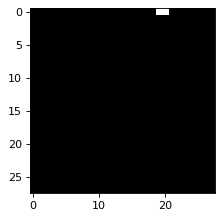

In [ ]:
plt.figure(figsize=(3, 3), dpi=80)
plt.imshow(mal_x[99], cmap="gray", vmin=0, vmax=1)
#plt.axis("off")

In [ ]:
def mergeCleanAndMaliciousWithSuffle(train_DATA_X,train_DATA_Y,M_x,M_y,shuffle=False):
    # train_DATA_X=np.concatenate((train_DATA_X,M_x),axis=0) # np.append(a, b)
    # train_DATA_Y=np.concatenate((train_DATA_Y,M_y),axis=0)


    n = train_DATA_X.shape[0]
    m = M_x.shape[0]
    train_DATA_X = np.resize(train_DATA_X, (n+m, train_DATA_X.shape[1], train_DATA_X.shape[2]))
    train_DATA_X[n:] = M_x
    train_DATA_Y = np.resize(train_DATA_Y, (n+m))
    train_DATA_Y[n:] = M_y


    if(shuffle == True):
        indices = np.random.permutation(train_DATA_Y.shape[0])
        np.random.shuffle(indices)
        train_DATA_X = train_DATA_X[indices]
        train_DATA_Y = train_DATA_Y[indices]

    print('Training Data_X :',train_DATA_X.shape)
    print('Training Data_y :',train_DATA_Y.shape)
    return train_DATA_X,train_DATA_Y

train_DATA_X,train_DATA_Y = mergeCleanAndMaliciousWithSuffle(train_DATA_X,train_DATA_Y,mal_x,mal_y,shuffle=True)

def shuffleData(train_DATA_X,train_DATA_Y):
    indices = np.random.permutation(train_DATA_Y.shape[0])
    np.random.shuffle(indices)
    train_DATA_X = train_DATA_X[indices]
    train_DATA_Y = train_DATA_Y[indices]
    return train_DATA_X,train_DATA_Y


Training Data_X : (60525, 28, 28)
Training Data_y : (60525,)


In [ ]:

print('Training Data :',train_DATA_X.shape)


Training Data : (60525, 28, 28)


In [ ]:
def printTestAccuracyandSavetheModel():
    model.save('mymodel2.h5')
    #model = tf.keras.models.load_model('ThreePatch2880_iteartion50.h5')
    print(len(TEST_BASELINE_Y))

    T_X=copy.deepcopy(TEST_BASELINE_X)
    T_Y=copy.deepcopy(TEST_BASELINE_Y)


    T_x = tf.keras.utils.normalize(T_X,axis=1)

    print(len(T_Y))
    # If problem appears then convert T_x into np array!

    val_loss1, val_acc1 = model.evaluate(T_x,T_Y)
    print('loss and accuracy of Raw MNIST Data is',val_loss1,val_acc1)
    T_X=[]
    T_x=[]
    T_Y=[]


#Helper Functions for Extracting the label in receiver

In [ ]:
from tensorflow.keras import backend as K



def trunc(values, decs=0):
    return np.trunc(values*10**decs)/(10**decs)


def printIndex(thelist):
    thelist=thelist.tolist()
    theset = frozenset(thelist)
    theset = sorted(theset, reverse=True)
    val= thelist.index(theset[0])
    #print(val)
    return val


def getLabel_Probabilities(TestSample,model):
  Total_Extracted_Val = []
  TestSample=np.array(TestSample)
  TestSample = tf.keras.utils.normalize(TestSample,axis=1)
  layerIndex = 7  # FOR Lenet-5
  func = K.function([model.get_layer(index=0).input], model.get_layer(index=layerIndex).output)
  layerOutput = func([TestSample])  # input_data is a numpy array
  len_output = layerOutput.shape[0]
  for i in range(len_output):
    k = printIndex(layerOutput[i])
    Total_Extracted_Val.append(k)
  return Total_Extracted_Val



def getLabel_ProbabilitiesfromPrediction(TestSample):
  TestSample=np.array(TestSample)
  TestSample = tf.keras.utils.normalize(TestSample,axis=1)
  extracted_Label = np.argmax(model.predict(TestSample), axis=-1)
  Total_Extracted_Val.append(extracted_Label)


def loadModel(modelName):
    model = tf.keras.models.load_model(modelName)
    sender_val=copy.deepcopy(Data)
    Total_Extracted_Val = getLabel_Probabilities(Patch_test_x,model) # query the model
    incorrect=0
    for i in range(lengthOfData):
      if(sender_val[i]!=Total_Extracted_Val[i]):
        incorrect+=1
    TOP1= (len(sender_val)-incorrect)/len(sender_val)
    print(len(Total_Extracted_Val), len(sender_val))
    print('Total incorrect before decoding: ',incorrect)
    print('Extraction Top-1 Accuracy: ',TOP1)

    T_X=copy.deepcopy(TEST_BASELINE_X)
    T_Y=copy.deepcopy(TEST_BASELINE_Y)


    T_x = tf.keras.utils.normalize(T_X,axis=1)

    print(len(T_Y))
    # If problem appears then convert T_x into np array!

    val_loss1, val_acc1 = model.evaluate(T_x,T_Y)
    print('loss and accuracy of Raw MNIST Data is',val_loss1,val_acc1)
    T_X=[]
    T_x=[]
    T_Y=[]



#Model Details

In [ ]:
model = keras.models.Sequential([
    keras.layers.Conv2D(6, kernel_size=5, strides=1,  activation='tanh', input_shape=(28,28,1), padding='same'), #C1
    keras.layers.AveragePooling2D(), #S2
    keras.layers.Conv2D(16, kernel_size=5, strides=1, activation='tanh', padding='valid'), #C3
    keras.layers.AveragePooling2D(), #S4
    keras.layers.Conv2D(120, kernel_size=5, strides=1, activation='tanh', padding='valid'), #C5
    keras.layers.Flatten(), #Flatten
    keras.layers.Dense(84, activation='tanh'), #F6
    keras.layers.Dense(10, activation='softmax') #Output layer
])



In [ ]:
inp = model.input
outputs = [layer.output for layer in model.layers]
print(outputs)
print(len(outputs))

[<KerasTensor: shape=(None, 28, 28, 6) dtype=float32 (created by layer 'conv2d_18')>, <KerasTensor: shape=(None, 14, 14, 6) dtype=float32 (created by layer 'average_pooling2d_12')>, <KerasTensor: shape=(None, 10, 10, 16) dtype=float32 (created by layer 'conv2d_19')>, <KerasTensor: shape=(None, 5, 5, 16) dtype=float32 (created by layer 'average_pooling2d_13')>, <KerasTensor: shape=(None, 1, 1, 120) dtype=float32 (created by layer 'conv2d_20')>, <KerasTensor: shape=(None, 120) dtype=float32 (created by layer 'flatten_6')>, <KerasTensor: shape=(None, 84) dtype=float32 (created by layer 'dense_12')>, <KerasTensor: shape=(None, 10) dtype=float32 (created by layer 'dense_13')>]
8


In [ ]:
from keras.callbacks import EarlyStopping
from tensorflow_privacy.privacy.optimizers.dp_optimizer_keras import DPKerasAdamOptimizer

def trainModel(model,train_DATA_X,train_DATA_Y):
    # Define early stopping callback
    early_stop = EarlyStopping(monitor='accuracy', min_delta=0.0001, patience=5)

    print("Model will be trained with ",len(train_DATA_X),' Data')
    print("\n--------------------------------------------------\n")

    # Set DP-SGD parameters
    noise_multiplier = 0.5         # Adjust this for your privacy-accuracy trade-off
    l2_norm_clip = 1.0             # Maximum L2 norm per-example gradient
    learning_rate = 0.001
    batch_size = 64
    nb_epoch = 100
    steps_per_epoch = len(train_DATA_X) // batch_size

    # Create the DP optimizer
    optimizer = DPKerasAdamOptimizer(
        l2_norm_clip=l2_norm_clip,
        noise_multiplier=noise_multiplier,
        num_microbatches=batch_size,  # Here, using the full batch as microbatches
        learning_rate=learning_rate
    )

    # Create a loss function that returns per-example losses
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=False,
        reduction=tf.keras.losses.Reduction.NONE  # Important for DP-SGD
    )

    # Compile the model with the DP optimizer and custom loss
    model.compile(optimizer=optimizer,
                  loss=loss_fn,
                  metrics=['accuracy'])

    # Assuming you have a batch generator similar to:
    # def batch_wise_Data_generator(X, y, batch_size, steps_per_epoch):
    #     while True:
    #         for i in range(steps_per_epoch):
    #             start = i * batch_size
    #             end = start + batch_size
    #             yield X[start:end], y[start:end]

    my_training_batch_generator = batch_wise_Data_generator(train_DATA_X, train_DATA_Y, batch_size, steps_per_epoch)

    # Train the model
    #model.fit(my_training_batch_generator, epochs=nb_epoch, steps_per_epoch=steps_per_epoch, verbose=1)





    # Train the model with early stopping
    model.fit(my_training_batch_generator,epochs=nb_epoch,steps_per_epoch=steps_per_epoch, callbacks=[early_stop])

    num_epochs= early_stop.stopped_epoch + 1
    if(early_stop.stopped_epoch == 0):
      num_epochs = nb_epoch
    print(f"Training stopped after {num_epochs} epochs.")
    return model,num_epochs


#Train the Model / Load Model

In [ ]:
TOP1_accuracy = 0
previous_TOP1_accuracy= -1
statistics=[]
round=0
total_epochs_used = 0
total_passes = 0
sender_val=copy.deepcopy(Data)
lengthOfData = len(sender_val)
flag= True
Prev_errorIndex = []
errorIndex = []
errorUpdate = False
accuracy_limit = 1
pass_threshold = 5773860
epoch_threshold = 100


#loadModel(modelName = 'BestModel2.h5')

In [ ]:
while TOP1_accuracy < accuracy_limit and total_epochs_used < epoch_threshold:
    round+=1

    model,num_epochs = trainModel(model,train_DATA_X,train_DATA_Y)  # Train the model
    total_epochs_used += num_epochs
    total_passes+= num_epochs* (CLEAN_DATA + MALICIOUS_DATA)
    Total_Extracted_Val = getLabel_Probabilities(copy.deepcopy(Patch_test_x),model) # query the model

    if(round != 1 and errorUpdate == True):
      Prev_errorIndex = copy.deepcopy(errorIndex)

    incorrect=0
    errorIndex=[]
    trackData=[]                                                    # Get error
    for i in range(lengthOfData):
      if(sender_val[i]!=Total_Extracted_Val[i]):
        incorrect+=1
        errorIndex.append(i)
        trackData.append(0)
      else:
        trackData.append(1)

    statistics.append(copy.deepcopy(trackData))

    print("\n--------------------------------------------------\n")
    print("End of Round: ",round)

    TOP1_accuracy= (len(sender_val)-incorrect)/len(sender_val)


    if(MALICIOUS_DATA > 2* CLEAN_DATA):# and accuracy_limit - TOP1_accuracy >= 0.05):
      required_samples = int(0.2*(MALICIOUS_DATA - CLEAN_DATA))
      n = int(np.ceil(required_samples/10))
      train_DATA_X,train_DATA_Y = addGANdata(train_DATA_X,train_DATA_Y,n)
      CLEAN_DATA += int(10*n)
      train_DATA_X,train_DATA_Y = shuffleData(train_DATA_X,train_DATA_Y)

    if(TOP1_accuracy >= previous_TOP1_accuracy):
      errorUpdate = True
      model.save('BestModel2.h5')
      previous_TOP1_accuracy = TOP1_accuracy
      print(len(Total_Extracted_Val), len(sender_val))
      print('Total incorrect before decoding: ',incorrect)
      print('Extraction Top-1 Accuracy: ',TOP1_accuracy)
      print("Total epochs used so far",total_epochs_used)
      print("Total passes: ",total_passes)
      print("total malicious data loaded: ",np.sum(LoadDataCount))
      print("Clean Data",CLEAN_DATA," Malicious Data ",np.sum(LoadDataCount))
      printTestAccuracyandSavetheModel()
      print()
      copy_sample = 10
      mal_train_x, mal_train_y= addExtraMaliciousData(Patch_test_x,Patch_test_y,
      errorIndex,repeatedSamples= copy_sample)
      if(len(mal_train_y) > 0):
          train_DATA_X,train_DATA_Y = mergeCleanAndMaliciousWithSuffle(train_DATA_X,
          train_DATA_Y,mal_train_x,mal_train_y,shuffle = True)
          MALICIOUS_DATA += int(len(errorIndex)*copy_sample)

    else:
      print("New Round Top-1 Accuracy ",TOP1_accuracy," is lower than previous round Top-1 Accuracy ",previous_TOP1_accuracy," : so training again")
      print("Total passes: ",total_passes)
      print("Clean Data",CLEAN_DATA," Malicious Data ",np.sum(LoadDataCount))

      copy_sample = 10
      mal_train_x, mal_train_y= addExtraMaliciousData(Patch_test_x,
                              Patch_test_y,Prev_errorIndex,repeatedSamples = copy_sample)
      if(len(mal_train_y) > 0):
          train_DATA_X,train_DATA_Y = mergeCleanAndMaliciousWithSuffle(train_DATA_X,
                                train_DATA_Y,mal_train_x,mal_train_y,shuffle= True)

          MALICIOUS_DATA += len(Prev_errorIndex)*copy_sample
          print("Clean Data",CLEAN_DATA," Malicious Data ",np.sum(LoadDataCount))
      errorUpdate = False


Model will be trained with  60525  Data

--------------------------------------------------

Epoch 1/100
945/945 [==============================] - 26s 25ms/step - loss: 0.8374 - accuracy: 0.7512
Epoch 2/100
945/945 [==============================] - 24s 25ms/step - loss: 0.4150 - accuracy: 0.8840
Epoch 3/100
945/945 [==============================] - 24s 25ms/step - loss: 0.3663 - accuracy: 0.9003
Epoch 4/100
945/945 [==============================] - 24s 26ms/step - loss: 0.3344 - accuracy: 0.9101
Epoch 5/100
945/945 [==============================] - 24s 25ms/step - loss: 0.3111 - accuracy: 0.9163
Epoch 6/100
945/945 [==============================] - 24s 25ms/step - loss: 0.2910 - accuracy: 0.9227
Epoch 7/100
945/945 [==============================] - 24s 26ms/step - loss: 0.2728 - accuracy: 0.9270
Epoch 8/100
945/945 [==============================] - 24s 26ms/step - loss: 0.2598 - accuracy: 0.9299
Epoch 9/100
945/945 [==============================] - 24s 26ms/step - loss: 0.2472

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


313/313 [==============================] - 1s 3ms/step - loss: 0.1622 - accuracy: 0.9615
loss and accuracy of Raw MNIST Data is 0.16220512986183167 0.9614999890327454

total Patch will be loaded:  90 
Each pattern will have  10  replicas
M_x shape:  (900, 28, 28)  M_y shape:  (900,)
Training Data_X : (61425, 28, 28)
Training Data_y : (61425,)
Model will be trained with  61425  Data

--------------------------------------------------

Epoch 1/100
959/959 [==============================] - 33s 32ms/step - loss: 0.2094 - accuracy: 0.9441
Epoch 2/100
959/959 [==============================] - 31s 32ms/step - loss: 0.2081 - accuracy: 0.9452
Epoch 3/100
959/959 [==============================] - 31s 32ms/step - loss: 0.2072 - accuracy: 0.9460
Epoch 4/100
959/959 [==============================] - 31s 32ms/step - loss: 0.2080 - accuracy: 0.9459
Epoch 5/100
959/959 [==============================] - 31s 32ms/step - loss: 0.2089 - accuracy: 0.9460
Epoch 6/100
959/959 [==========================

In [ ]:
printTestAccuracyandSavetheModel()

10000
10000
313/313 [==============================] - 1s 3ms/step - loss: 0.1982 - accuracy: 0.9615
loss and accuracy of Raw MNIST Data is 0.19816280901432037 0.9614999890327454


#Retrive All Data

In [ ]:
sender_val=copy.deepcopy(Data)

print(len(Total_Extracted_Val), len(sender_val))

incorrect=0
for i in range(len(sender_val)):
  if(sender_val[i]!=Total_Extracted_Val[i]):
    incorrect+=1

print('Total incorrect before decoding: ',incorrect)
TOP1_accuracy= (len(sender_val)-incorrect)/len(sender_val)
TOP1_ErrorCount = incorrect
print('Extraction Top-1 Accuracy: ',TOP1_accuracy)

105 105
Total incorrect before decoding:  69
Extraction Top-1 Accuracy:  0.34285714285714286


# Epsilon and Delta

In [ ]:
from tensorflow_privacy.privacy.analysis import compute_dp_sgd_privacy_lib

# --- Privacy Accounting ---
delta = 1e-5  # less than the inverse to the size of dataset
data_size = len(train_DATA_X)  # total number of training examples
print(data_size,total_epochs_used)

epsilon, optimal_order = compute_dp_sgd_privacy_lib.compute_dp_sgd_privacy(
    n=data_size,
    batch_size=64,
    noise_multiplier=0.5,
    epochs=100,
    delta=delta
)

print("For delta =", delta, "the current epsilon is:", epsilon)

62060 107
For delta = 1e-05 the current epsilon is: 14.850140396362292
